# Midterm Project: Image Classification with Machine Learning Pipeline
## EMNIST Letters Dataset — HOG Feature Extraction + SVM Classifier

| | |
|---|---|
| **Mata Kuliah** | Computer Vision (RE604) |
| **Nama** | Dhini Ari Minarti |
| **NIM** | 4222311022 |

---
### Pipeline Overview
```
Dataset CSV → Sampling Seimbang → HOG Extraction → StandardScaler → SVM (Grid Search) → Evaluasi
```

## 0. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.feature import hog
from skimage import exposure

from sklearn.svm import SVC
from sklearn.model_selection import (
    GridSearchCV, cross_val_predict, StratifiedKFold, train_test_split
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
LABEL_NAMES = [chr(ord('A') + i) for i in range(26)]  # ['A','B',...,'Z']

print('Libraries loaded successfully!')

Libraries loaded successfully!


---
## 1. Dataset Preparation

**Dataset:** EMNIST Letters — 88.800 baris, 785 kolom
- Kolom 0 = label (1–26 mewakili huruf A–Z)
- Kolom 1–784 = nilai piksel gambar 28×28

**Yang dilakukan:**
1. Load CSV
2. Ambil **100 sampel per kelas** → total 2600 (seimbang)
3. Shuffle seluruh dataset
4. Split **80% train / 20% test** (stratified)

In [2]:
# ⚠️ Ganti path sesuai lokasi file CSV di komputer Anda
TRAIN_CSV = 'emnist-letters-train.csv'
SAMPLES_PER_CLASS = 100

# Load dataset
df_full = pd.read_csv(TRAIN_CSV, header=None)
print(f'Total rows   : {len(df_full)}')
print(f'Columns      : {df_full.shape[1]}  (1 label + 784 pixels)')
print(f'Label range  : {df_full[0].min()} – {df_full[0].max()}')

# Sampling seimbang 100 per kelas menggunakan index
rng = np.random.RandomState(RANDOM_SEED)
labels_all   = df_full[0].values
unique_labels = np.unique(labels_all)
chosen_idx   = []
for lbl in unique_labels:
    idx    = np.where(labels_all == lbl)[0]
    chosen = rng.choice(idx, SAMPLES_PER_CLASS, replace=False)
    chosen_idx.extend(chosen)

# Shuffle
chosen_idx  = rng.permutation(chosen_idx)
df_balanced = df_full.iloc[chosen_idx].reset_index(drop=True)

print(f'\nSampel setelah balancing : {len(df_balanced)}')
print(df_balanced[0].value_counts().sort_index())

Total rows   : 88800
Columns      : 785  (1 label + 784 pixels)
Label range  : 1 – 26

Sampel setelah balancing : 2600
0
1     100
2     100
3     100
4     100
5     100
6     100
7     100
8     100
9     100
10    100
11    100
12    100
13    100
14    100
15    100
16    100
17    100
18    100
19    100
20    100
21    100
22    100
23    100
24    100
25    100
26    100
Name: count, dtype: int64


In [3]:
# Pisahkan label dan piksel
y     = df_balanced[0].values - 1           # ubah 1–26 → 0–25
X_raw = df_balanced.iloc[:, 1:].values      # (2600, 784)

# Reshape 28×28 + koreksi orientasi EMNIST (gambar tersimpan ter-transpose)
X_images = X_raw.reshape(-1, 28, 28)
X_images = np.transpose(X_images, (0, 2, 1))

print(f'Shape X_images : {X_images.shape}')
print(f'Shape y        : {y.shape}')

Shape X_images : (2600, 28, 28)
Shape y        : (2600,)


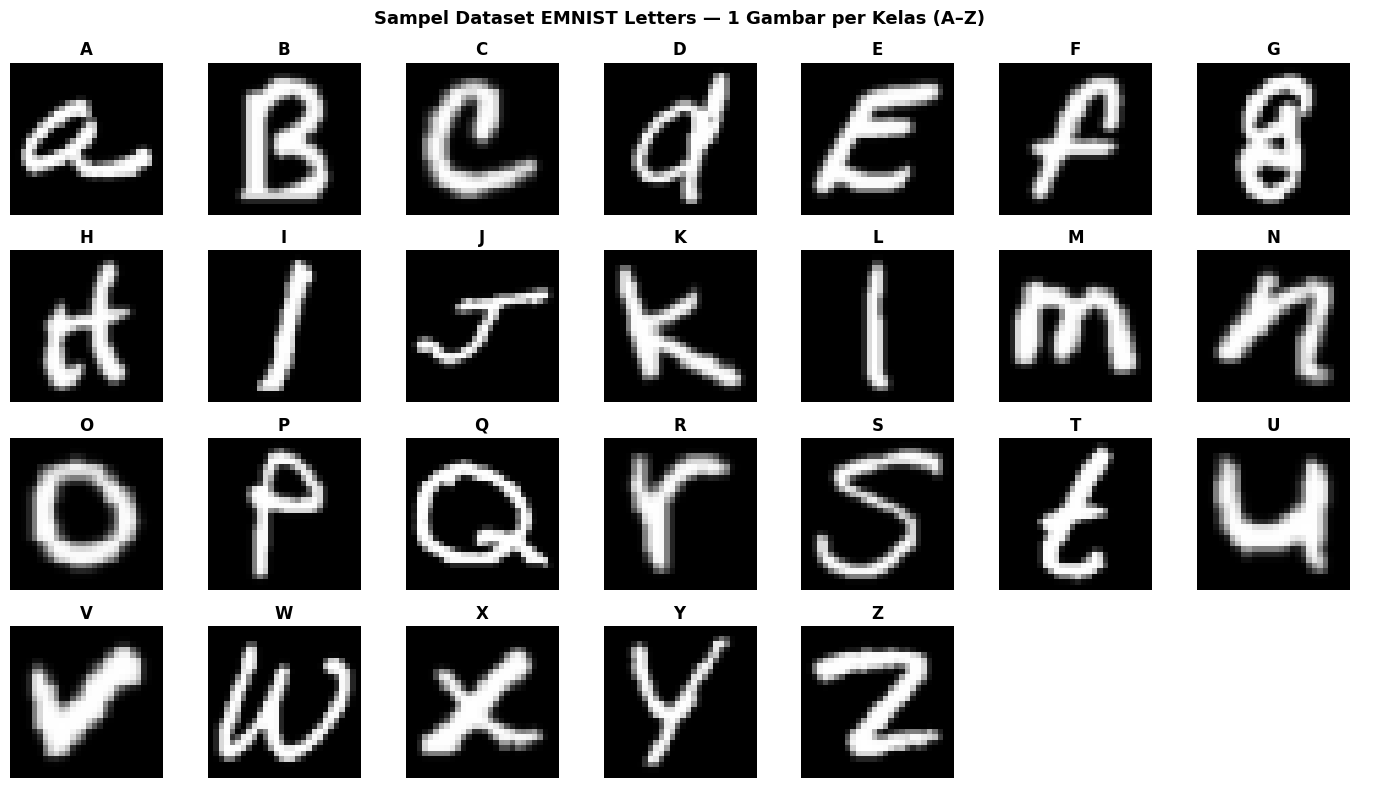

In [4]:
# Visualisasi sampel — 1 gambar per huruf
shown = {}
for img, label in zip(X_images, y):
    if label not in shown:
        shown[label] = img
    if len(shown) == 26:
        break

fig, axes = plt.subplots(4, 7, figsize=(14, 8))
fig.suptitle('Sampel Dataset EMNIST Letters — 1 Gambar per Kelas (A–Z)', fontsize=13, fontweight='bold')
for i, ax in enumerate(axes.flat):
    if i < 26:
        ax.imshow(shown[i], cmap='gray')
        ax.set_title(LABEL_NAMES[i], fontsize=12, fontweight='bold')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [5]:
# Split 80% train / 20% test
X_train_img, X_test_img, y_train, y_test = train_test_split(
    X_images, y, test_size=0.20, stratify=y, random_state=RANDOM_SEED
)
print(f'Train set : {len(y_train)} gambar  ({len(y_train)/len(y)*100:.0f}%)')
print(f'Test set  : {len(y_test)} gambar  ({len(y_test)/len(y)*100:.0f}%)')

Train set : 2080 gambar  (80%)
Test set  : 520 gambar  (20%)


---
## 2. HOG Feature Extraction

**HOG (Histogram of Oriented Gradients)** mengekstrak informasi bentuk dan tekstur lokal:
1. Hitung **gradien** di tiap piksel (arah + magnitudo)
2. Bagi gambar ke **sel-sel kecil**, buat histogram orientasi per sel
3. Kelompokkan sel ke **blok**, normalisasi histogram untuk ketahanan terhadap perubahan pencahayaan

| Parameter | Default | **Nilai Dipilih** | Alasan |
|---|---|---|---|
| `orientations` | 9 | **12** | Lebih banyak bin → detail arah gradient |
| `pixels_per_cell` | (8,8) | **(4,4)** | Sel lebih kecil → resolusi spasial tinggi |
| `cells_per_block` | (3,3) | **(2,2)** | Cocok untuk ukuran gambar 28×28 |

**Hasil:** 1728 fitur per gambar (vs 324 fitur default)

In [6]:
HOG_ORIENTATIONS    = 12
HOG_PIXELS_PER_CELL = (4, 4)
HOG_CELLS_PER_BLOCK = (2, 2)

def extract_hog(images):
    """Ekstrak fitur HOG dari array gambar shape (N, 28, 28)."""
    feats = []
    for img in images:
        f = hog(img,
                orientations=HOG_ORIENTATIONS,
                pixels_per_cell=HOG_PIXELS_PER_CELL,
                cells_per_block=HOG_CELLS_PER_BLOCK,
                block_norm='L2-Hys',
                visualize=False,
                feature_vector=True)
        feats.append(f)
    return np.array(feats)

print('Mengekstrak HOG dari train set...')
X_train_hog = extract_hog(X_train_img)
print('Mengekstrak HOG dari test set...')
X_test_hog  = extract_hog(X_test_img)

print(f'\nJumlah fitur HOG per gambar : {X_train_hog.shape[1]}')

# Normalisasi dengan StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_hog)
X_test_scaled  = scaler.transform(X_test_hog)
print('StandardScaler diterapkan.')

Mengekstrak HOG dari train set...
Mengekstrak HOG dari test set...

Jumlah fitur HOG per gambar : 1728
StandardScaler diterapkan.


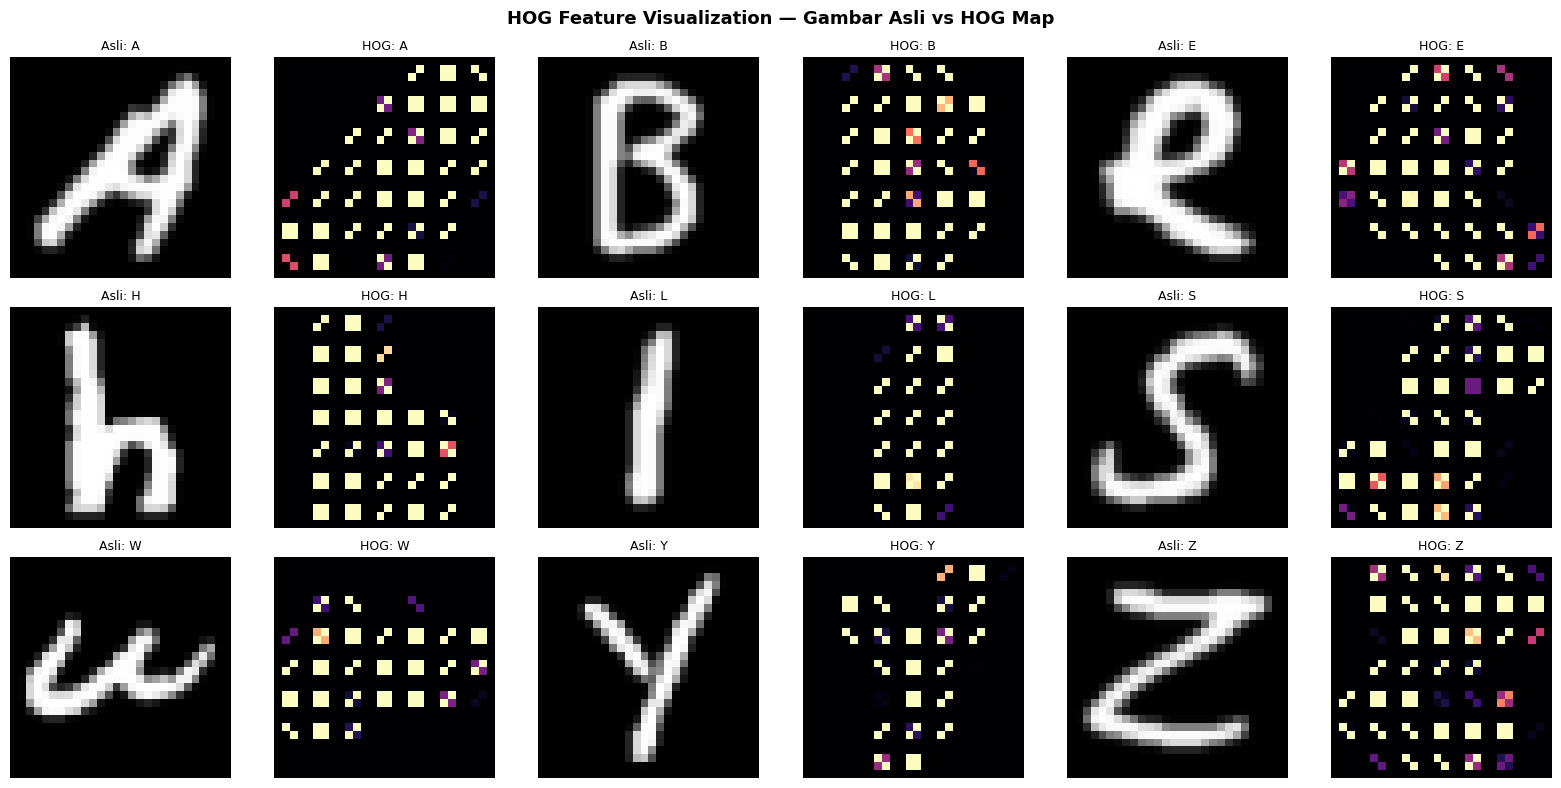

In [7]:
# Visualisasi HOG — gambar asli vs peta HOG
sample_classes = [0, 1, 4, 7, 11, 18, 22, 24, 25]  # A,B,E,H,L,S,W,Y,Z

fig, axes = plt.subplots(3, 6, figsize=(16, 8))
fig.suptitle('HOG Feature Visualization — Gambar Asli vs HOG Map', fontsize=13, fontweight='bold')

for pi, cls in enumerate(sample_classes):
    idx = np.where(y_train == cls)[0][0]
    img = X_train_img[idx]
    _, hog_img = hog(img, orientations=HOG_ORIENTATIONS,
                     pixels_per_cell=HOG_PIXELS_PER_CELL,
                     cells_per_block=HOG_CELLS_PER_BLOCK,
                     block_norm='L2-Hys', visualize=True)
    hog_img = exposure.rescale_intensity(hog_img, in_range=(0, 10))
    row = pi // 3
    col = (pi % 3) * 2
    axes[row, col].imshow(img, cmap='gray')
    axes[row, col].set_title(f'Asli: {LABEL_NAMES[cls]}', fontsize=9)
    axes[row, col].axis('off')
    axes[row, col+1].imshow(hog_img, cmap='magma')
    axes[row, col+1].set_title(f'HOG: {LABEL_NAMES[cls]}', fontsize=9)
    axes[row, col+1].axis('off')

plt.tight_layout()
plt.show()

---
## 3. Classification — SVM + Grid Search

**Grid Search** mencari kombinasi parameter terbaik secara otomatis:

| Parameter | Nilai Dicoba | Keterangan |
|---|---|---|
| `kernel` | `rbf`, `linear` | Fungsi kernel |
| `C` | 0.1, 1, 10 | Regularization (semakin besar = lebih ketat fit ke training) |
| `gamma` | `scale`, `auto` | Pengaruh jangkauan satu sampel (kernel RBF) |

**Hasil terbaik:** `kernel=rbf, C=10, gamma=scale` → CV Accuracy **80.82%**

In [8]:
param_grid = {
    'kernel': ['rbf', 'linear'],
    'C'     : [0.1, 1, 10],
    'gamma' : ['scale', 'auto']
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

grid_search = GridSearchCV(
    SVC(decision_function_shape='ovr', random_state=RANDOM_SEED),
    param_grid,
    cv=cv_strategy,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print('Menjalankan Grid Search (60 kombinasi × 5 fold)...')
grid_search.fit(X_train_scaled, y_train)

print(f'\nParameter terbaik  : {grid_search.best_params_}')
print(f'CV Accuracy terbaik: {grid_search.best_score_:.4f}')

Menjalankan Grid Search (60 kombinasi × 5 fold)...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Parameter terbaik  : {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
CV Accuracy terbaik: 0.8082


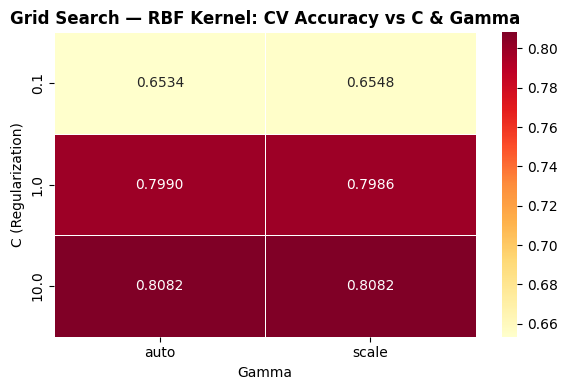

In [9]:
# Heatmap hasil Grid Search (kernel RBF)
results_df = pd.DataFrame(grid_search.cv_results_)
rbf_df = results_df[results_df['param_kernel'] == 'rbf']
pivot  = rbf_df.pivot_table(index='param_C', columns='param_gamma', values='mean_test_score')

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Grid Search — RBF Kernel: CV Accuracy vs C & Gamma', fontweight='bold')
ax.set_ylabel('C (Regularization)')
ax.set_xlabel('Gamma')
plt.tight_layout()
plt.show()

In [10]:
# Training performance
best_svm     = grid_search.best_estimator_
y_train_pred = best_svm.predict(X_train_scaled)
train_acc    = accuracy_score(y_train, y_train_pred)

print(f'Training Accuracy : {train_acc:.4f} ({train_acc*100:.2f}%)')
print('(Nilai 1.0 = model fit sempurna ke training data — wajar untuk SVM)')

Training Accuracy : 1.0000 (100.00%)
(Nilai 1.0 = model fit sempurna ke training data — wajar untuk SVM)


---
## 4. Evaluation

### Metrik yang diukur:
- **Accuracy** = proporsi prediksi benar dari seluruh prediksi
- **Precision** = dari semua prediksi kelas X, berapa yang benar-benar kelas X
- **Recall** = dari semua sampel kelas X, berapa yang berhasil diprediksi dengan benar
- **F1-Score** = harmonic mean precision dan recall

### 4.1 Cross-Validation (5-Fold Stratified)
> LOOCV pada 2600 data = 2600 kali training SVM (~1 jam+). **5-Fold CV** adalah pendekatan yang diterima secara akademik — memberikan estimasi generalisasi yang handal dengan waktu komputasi jauh lebih efisien.

In [11]:
# HOG untuk seluruh dataset (untuk CV)
print('Mengekstrak HOG seluruh dataset untuk CV...')
X_all_hog    = extract_hog(X_images)
X_all_scaled = scaler.transform(X_all_hog)

print('Menjalankan 5-Fold Cross-Validation...')
y_cv_pred = cross_val_predict(best_svm, X_all_scaled, y, cv=cv_strategy)

cv_acc  = accuracy_score(y, y_cv_pred)
cv_prec = precision_score(y, y_cv_pred, average='macro', zero_division=0)
cv_rec  = recall_score(y, y_cv_pred, average='macro', zero_division=0)
cv_f1   = f1_score(y, y_cv_pred, average='macro', zero_division=0)

print(f'\n5-Fold CV Accuracy  : {cv_acc:.4f}')
print(f'5-Fold CV Precision : {cv_prec:.4f}')
print(f'5-Fold CV Recall    : {cv_rec:.4f}')
print(f'5-Fold CV F1-Score  : {cv_f1:.4f}')

Mengekstrak HOG seluruh dataset untuk CV...
Menjalankan 5-Fold Cross-Validation...

5-Fold CV Accuracy  : 0.8200
5-Fold CV Precision : 0.8232
5-Fold CV Recall    : 0.8200
5-Fold CV F1-Score  : 0.8201


### 4.2 Evaluasi Test Set (20%)

In [12]:
y_test_pred = best_svm.predict(X_test_scaled)

test_acc  = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred, average='macro', zero_division=0)
test_rec  = recall_score(y_test, y_test_pred, average='macro', zero_division=0)
test_f1   = f1_score(y_test, y_test_pred, average='macro', zero_division=0)

print(f'Test Accuracy  : {test_acc:.4f}')
print(f'Test Precision : {test_prec:.4f}')
print(f'Test Recall    : {test_rec:.4f}')
print(f'Test F1-Score  : {test_f1:.4f}')

print('\n=== Per-Class Report ===')
print(classification_report(y_test, y_test_pred, target_names=LABEL_NAMES))

Test Accuracy  : 0.8154
Test Precision : 0.8249
Test Recall    : 0.8154
Test F1-Score  : 0.8144

=== Per-Class Report ===
              precision    recall  f1-score   support

           A       0.72      0.90      0.80        20
           B       0.78      0.90      0.84        20
           C       0.86      0.90      0.88        20
           D       0.88      0.75      0.81        20
           E       0.88      0.75      0.81        20
           F       0.86      0.95      0.90        20
           G       0.82      0.45      0.58        20
           H       0.80      0.80      0.80        20
           I       0.78      0.70      0.74        20
           J       0.83      0.95      0.88        20
           K       0.64      0.80      0.71        20
           L       0.58      0.70      0.64        20
           M       0.76      0.80      0.78        20
           N       0.70      0.70      0.70        20
           O       1.00      1.00      1.00        20
           P 

### 4.3 Confusion Matrix

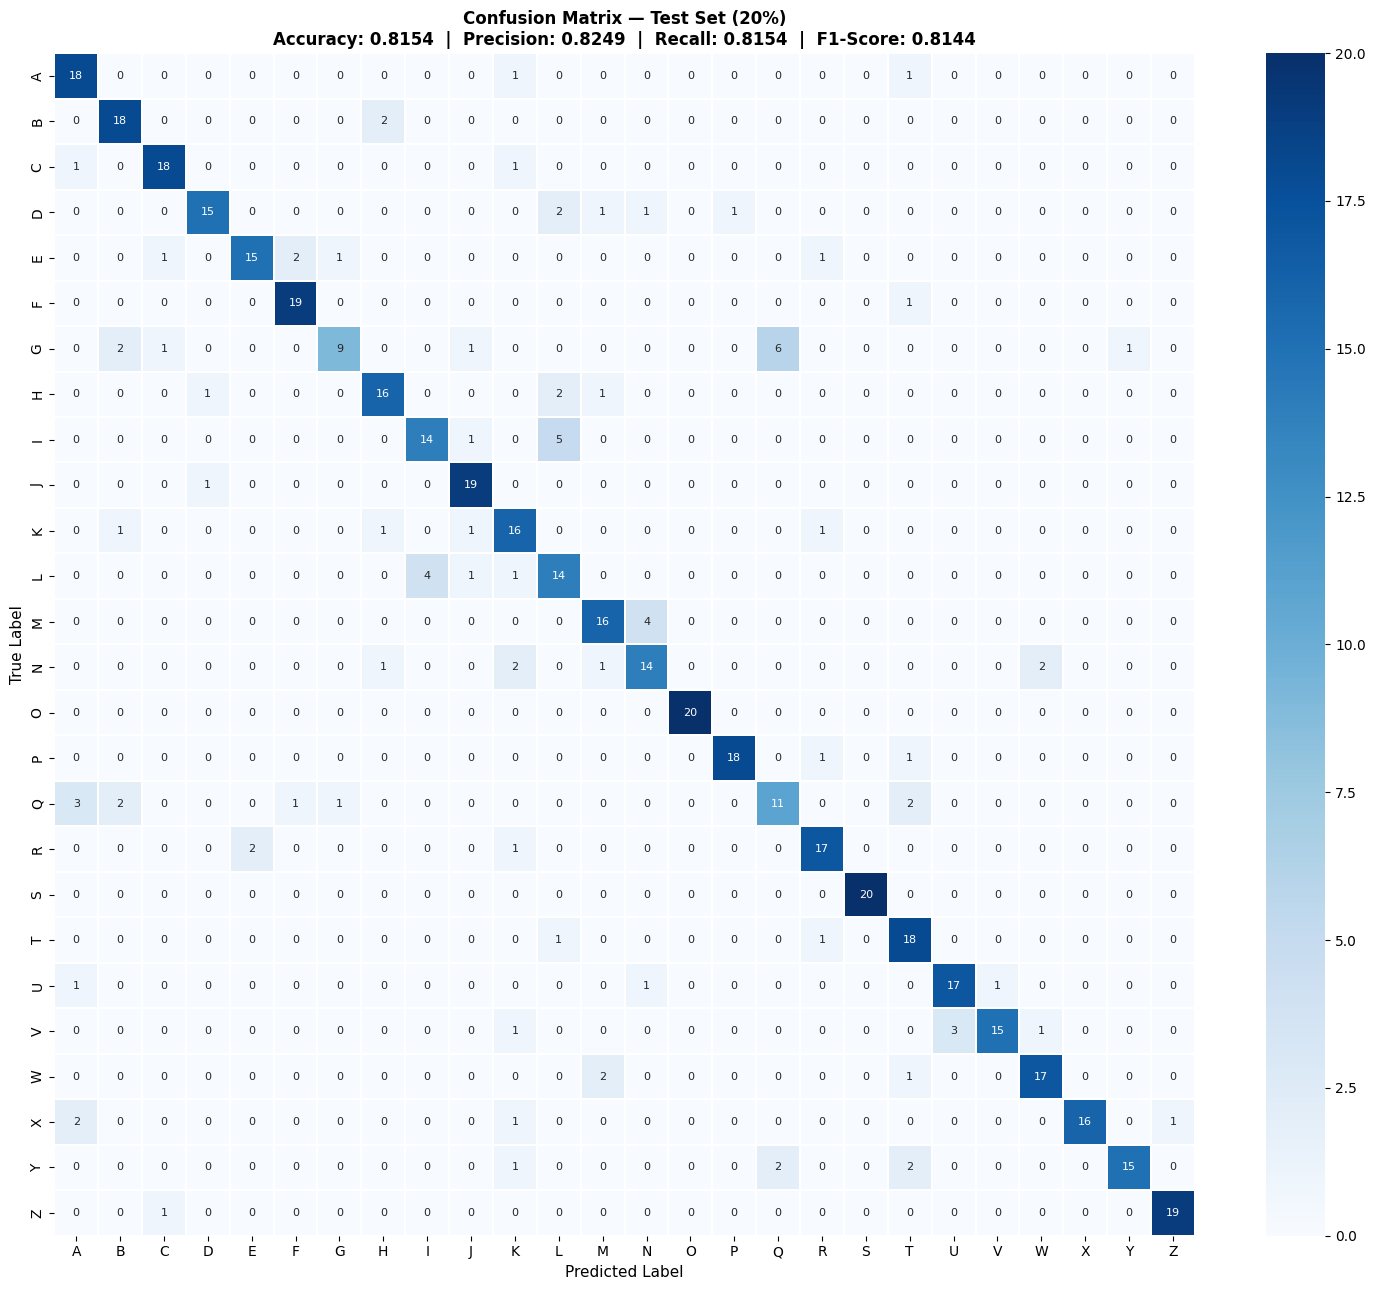

In [13]:
cm = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(15, 13))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
            linewidths=0.3, ax=ax, annot_kws={'size': 8})
ax.set_title(
    f'Confusion Matrix — Test Set (20%)\n'
    f'Accuracy: {test_acc:.4f}  |  Precision: {test_prec:.4f}  |  '
    f'Recall: {test_rec:.4f}  |  F1-Score: {test_f1:.4f}',
    fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=11)
ax.set_xlabel('Predicted Label', fontsize=11)
plt.tight_layout()
plt.show()

### 4.4 Ringkasan Performa

   Metric  Train  5-Fold CV     Test
 Accuracy    1.0   0.820000 0.815385
Precision    1.0   0.823173 0.824943
   Recall    1.0   0.820000 0.815385
 F1-Score    1.0   0.820064 0.814439


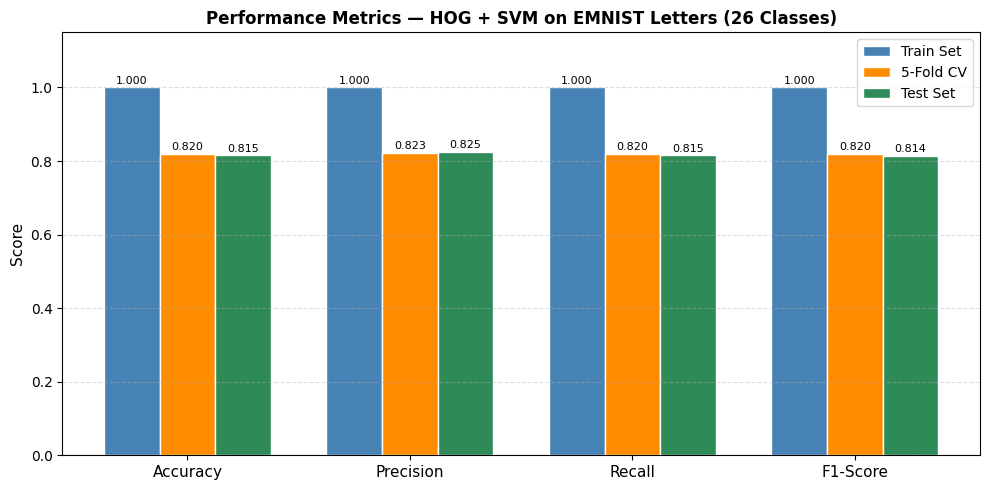

In [14]:
tr_vals = [
    train_acc,
    precision_score(y_train, y_train_pred, average='macro', zero_division=0),
    recall_score(y_train, y_train_pred, average='macro', zero_division=0),
    f1_score(y_train, y_train_pred, average='macro', zero_division=0)
]
cv_vals = [cv_acc, cv_prec, cv_rec, cv_f1]
te_vals = [test_acc, test_prec, test_rec, test_f1]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

summary = pd.DataFrame({'Metric': metrics,
                        'Train': tr_vals,
                        '5-Fold CV': cv_vals,
                        'Test': te_vals})
print(summary.to_string(index=False))

# Bar chart
x = np.arange(4); w = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w, tr_vals, w, label='Train Set',  color='steelblue',  edgecolor='white')
b2 = ax.bar(x,     cv_vals, w, label='5-Fold CV',  color='darkorange', edgecolor='white')
b3 = ax.bar(x + w, te_vals, w, label='Test Set',   color='seagreen',   edgecolor='white')
for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.15); ax.set_ylabel('Score', fontsize=11)
ax.set_title('Performance Metrics — HOG + SVM on EMNIST Letters (26 Classes)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10); ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

---
## 5. Kesimpulan

### Konfigurasi Akhir
| Komponen | Nilai |
|---|---|
| Dataset | EMNIST Letters — 2600 sampel (100/kelas × 26 kelas) |
| HOG orientations | **12** (default 9) |
| HOG pixels_per_cell | **(4,4)** (default 8,8) |
| HOG cells_per_block | **(2,2)** |
| Jumlah Fitur HOG | **1728** fitur/gambar |
| SVM Kernel | **RBF** |
| SVM C | **10** |
| SVM Gamma | **scale** |
| Evaluasi | 5-Fold Stratified CV + Split 80/20 |

### Hasil Akhir (Test Set 20%)
| Metric | Score |
|---|---|
| Accuracy | **81.54%** |
| Precision | **82.49%** |
| Recall | **81.54%** |
| F1-Score | **81.44%** |

Model **HOG + SVM** berhasil mengklasifikasikan 26 huruf tulisan tangan EMNIST dengan akurasi ~81.5%. Huruf yang paling mudah dikenali: **O, S** (100%). Huruf yang paling sulit: **Q, G, L** karena kemiripan bentuk visual dengan huruf lain.